In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="bbZsMtcHlx6j0OaJ6lJb")
project = rf.workspace("stuti").project("road-defect-detection-2zice")
version = project.version(16)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Road-defect-detection-16 in yolov8:: 100%|██████████| 678/678 [00:00<00:00, 2352.86it/s]


In [ ]:
print(dataset.location)

/content/Road-defect-detection-16


In [ ]:
!ls /content/Road-defect-detection-16

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
data_path = dataset.location
print(f"Dataset path: {data_path}")

Dataset path: /content/Road-defect-detection-16


In [ ]:
import os

def verify_dataset_structure(dataset_path):
    required_dirs = ['train', 'valid']
    required_subdirs = ['images', 'labels']

    for folder in required_dirs:
        folder_path = os.path.join(dataset_path, folder)

        # Check if the train/valid folders exist
        if not os.path.exists(folder_path):
            print(f"Error: '{folder}' folder is missing in the dataset path.")
            continue

        for subfolder in required_subdirs:
            subfolder_path = os.path.join(folder_path, subfolder)

            # Check if images and labels subfolders exist
            if not os.path.exists(subfolder_path):
                print(f"Error: '{subfolder}' folder is missing in '{folder}'.")
            else:
                # Count the number of files in each subfolder
                files = os.listdir(subfolder_path)
                print(f"'{subfolder}' folder in '{folder}' contains {len(files)} files.")

    # Check if every image has a corresponding annotation file
    for folder in required_dirs:
        images_folder = os.path.join(dataset_path, folder, 'images')
        labels_folder = os.path.join(dataset_path, folder, 'labels')

        if os.path.exists(images_folder) and os.path.exists(labels_folder):
            image_files = set([os.path.splitext(f)[0] for f in os.listdir(images_folder)])
            label_files = set([os.path.splitext(f)[0] for f in os.listdir(labels_folder)])

            missing_labels = image_files - label_files
            missing_images = label_files - image_files

            if missing_labels:
                print(f"Images without annotations in '{folder}': {missing_labels}")
            if missing_images:
                print(f"Annotations without images in '{folder}': {missing_images}")
            if not missing_labels and not missing_images:
                print(f"All images have corresponding annotations in '{folder}'.")
        else:
            print(f"Error: Images or labels folder missing in '{folder}'.")

# Set your dataset path (update this with your actual dataset folder path)
dataset_path = "/content/Road-defect-detection-16"  # Replace this with the path to your dataset
verify_dataset_structure(dataset_path)


'images' folder in 'train' contains 233 files.
'labels' folder in 'train' contains 233 files.
'images' folder in 'valid' contains 65 files.
'labels' folder in 'valid' contains 65 files.
All images have corresponding annotations in 'train'.
All images have corresponding annotations in 'valid'.


In [ ]:
import os

# Paths to images and labels
train_labels_path = "/content/Road-defect-detection-16/train/labels"
val_labels_path = "/content/Road-defect-detection-16/valid/labels"

# List all annotation files
train_annotations = os.listdir(train_labels_path)
val_annotations = os.listdir(val_labels_path)

# Example: Display a sample annotation file
sample_annotation_file = os.path.join(train_labels_path, train_annotations[0])
with open(sample_annotation_file, "r") as f:
    print(f"Sample annotation ({sample_annotation_file}):")
    print(f.read())


Sample annotation (/content/Road-defect-detection-16/train/labels/India_005557_jpg.rf.a6d353c62a391a0fd14626e29ce0b512.txt):
1 0.3793194444444445 0.8362638888888889 0.15995833333333334 0.17377777777777778


In [ ]:
from collections import Counter
import os

def count_classes(labels_path):
    class_counts = Counter()
    for label_file in os.listdir(labels_path):
        with open(os.path.join(labels_path, label_file), "r") as f:
            for line in f:
                class_id = line.split()[0]  # Class ID is the first value in each line
                class_counts[class_id] += 1
    return class_counts

# Paths to train and valid labels
train_labels_path = "/content/Road-defect-detection-16/train/labels"  # Update this path if needed
valid_labels_path = "/content/Road-defect-detection-16/valid/labels"  # Update this path if needed

# Count classes in training and validation sets
train_counts = count_classes(train_labels_path)
valid_counts = count_classes(valid_labels_path)

print("Training set class counts:", train_counts)
print("Validation set class counts:", valid_counts)


Training set class counts: Counter({'0': 173, '1': 82})
Validation set class counts: Counter({'0': 57, '1': 31})


In [ ]:
import os
import shutil
from collections import Counter

def oversample_class(labels_path, images_path, class_id, target_count):
    # Count instances of the target class
    class_files = []
    for label_file in os.listdir(labels_path):
        label_path = os.path.join(labels_path, label_file)
        with open(label_path, "r") as f:
            # Check if the file contains the target class
            if any(line.startswith(str(class_id)) for line in f):
                class_files.append(label_file)

    print(f"Found {len(class_files)} files with class '{class_id}'. Oversampling to {target_count}.")

    # Duplicate files to match the target count
    while len(class_files) < target_count:
        for file in class_files:
            if len(class_files) >= target_count:
                break
            # Duplicate the label file
            original_label_path = os.path.join(labels_path, file)
            new_label_path = os.path.join(labels_path, f"{file.split('.')[0]}_dup.txt")
            shutil.copy(original_label_path, new_label_path)

            # Duplicate the corresponding image file
            original_image_path = os.path.join(images_path, file.replace(".txt", ".jpg"))
            new_image_path = os.path.join(images_path, f"{file.split('.')[0]}_dup.jpg")
            shutil.copy(original_image_path, new_image_path)

            class_files.append(f"{file.split('.')[0]}_dup.txt")

    print(f"After oversampling, class '{class_id}' has {len(class_files)} samples.")

# Paths to labels and images
train_labels_path = "/content/Road-defect-detection-16/train/labels"
train_images_path = "/content/Road-defect-detection-16/train/images"

# Oversample class '1' to match the count of class '0'
oversample_class(train_labels_path, train_images_path, class_id=1, target_count=173)


Found 62 files with class '1'. Oversampling to 173.
After oversampling, class '1' has 173 samples.


In [ ]:
# Paths to labels and images for validation set
val_labels_path = "/content/Road-defect-detection-16/valid/labels"
val_images_path = "/content/Road-defect-detection-16/valid/images"

# Oversample class '1' to match the count of class '0'
oversample_class(val_labels_path, val_images_path, class_id=1, target_count=57)


Found 17 files with class '1'. Oversampling to 57.
After oversampling, class '1' has 57 samples.


In [ ]:
def count_instances(labels_path):
    class_counts = Counter()
    for label_file in os.listdir(labels_path):
        with open(os.path.join(labels_path, label_file), "r") as f:
            for line in f:
                class_id = line.split()[0]  # First column is the class ID
                class_counts[class_id] += 1
    return class_counts

# Count instances in training and validation datasets
train_counts = count_instances(train_labels_path)
val_counts = count_instances(val_labels_path)

print("Balanced Training set class counts:", train_counts)
print("Balanced Validation set class counts:", val_counts)


Balanced Training set class counts: Counter({'1': 230, '0': 203})
Balanced Validation set class counts: Counter({'1': 103, '0': 68})


In [ ]:
import cv2
import os

def resize_images(folder_path, output_path, img_size=640):
    os.makedirs(output_path, exist_ok=True)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        resized_img = cv2.resize(img, (img_size, img_size))
        cv2.imwrite(os.path.join(output_path, img_file), resized_img)

# Resize training images
resize_images('/content/Road-defect-detection-16/train/images', 'path_to_resized_train_images', img_size=640)

# Resize validation images
resize_images('/content/Road-defect-detection-16/valid/images', 'path_to_resized_valid_images', img_size=640)


In [ ]:
import cv2
import numpy as np
import os
import random

def histogram_equalization(image):
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply histogram equalization
    equalized = cv2.equalizeHist(gray)
    # Convert back to BGR to maintain consistency
    return cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)

def zoom_image(image, zoom_factor=1.2):
    # Get the center of the image
    height, width = image.shape[:2]
    center = (width // 2, height // 2)

    # Define the transformation matrix for zoom
    matrix = cv2.getRotationMatrix2D(center, 0, zoom_factor)
    # Apply the zoom transformation
    zoomed_image = cv2.warpAffine(image, matrix, (width, height))
    return zoomed_image

def flip_image(image):
    # Randomly flip the image horizontally or vertically
    flip_type = random.choice([-1, 0, 1])  # -1: flip both axes, 0: flip vertically, 1: flip horizontally
    return cv2.flip(image, flip_type)

def preprocess_image(image, img_size=640):
    # Resize the image
    image_resized = cv2.resize(image, (img_size, img_size))

    # Apply Histogram Equalization
    image_equalized = histogram_equalization(image_resized)

    # Apply Zoom
    image_zoomed = zoom_image(image_equalized)

    # Apply Flip
    image_flipped = flip_image(image_zoomed)

    return image_flipped

def preprocess_images(folder_path, output_path, img_size=640):
    os.makedirs(output_path, exist_ok=True)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        processed_img = preprocess_image(img, img_size)
        cv2.imwrite(os.path.join(output_path, img_file), processed_img)

    print(f"Preprocessed images saved to {output_path}")

# Example usage
# Resize, equalize, zoom, and flip training images
preprocess_images('/content/Road-defect-detection-16/train/images', 'path_to_preprocessed_train_images', img_size=640)

# Resize, equalize, zoom, and flip validation images
preprocess_images('/content/Road-defect-detection-16/valid/images', 'path_to_preprocessed_valid_images', img_size=640)


Preprocessed images saved to path_to_preprocessed_train_images
Preprocessed images saved to path_to_preprocessed_valid_images


In [ ]:
!pip install -q roboflow ultralytics albumentations opencv-python

import os
import cv2
import shutil
import yaml
import numpy as np
import albumentations as A
from roboflow import Roboflow
from sklearn.model_selection import KFold
from ultralytics import YOLO


In [ ]:
# Install necessary libraries
!pip install -q roboflow ultralytics albumentations opencv-python

import os
import shutil
import yaml
import numpy as np
from sklearn.model_selection import KFold
from ultralytics import YOLO

# === Step 1: CLEAN OLD DATA ===
print("🚀 Cleaning old data...")

paths_to_delete = [
    "/content/yolo_cv_results",
    "/content/train_fold_*",
    "/content/val_fold_*",
    "/content/data_fold_*.yaml"
]

for path in paths_to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)  # Remove folder and contents

print("✅ Old data removed!")

# === Step 2: DEFINE DATASET PATHS ===
dataset_dir = "/content/Road-defect-detection-16"
train_dir = os.path.join(dataset_dir, "train")
valid_dir = os.path.join(dataset_dir, "valid")
test_dir = os.path.join(dataset_dir, "test")

# Ensure dataset is correctly structured
assert os.path.exists(train_dir), "❌ Train folder missing!"
assert os.path.exists(valid_dir), "❌ Validation folder missing!"
assert os.path.exists(test_dir), "❌ Test folder missing!"

# === Step 3: CLEAN LABEL FILES (REMOVE UNWANTED CLASSES) ===
print("🛠 Cleaning label files...")

label_dirs = [os.path.join(train_dir, "labels"), os.path.join(valid_dir, "labels")]

for label_dir in label_dirs:
    for filename in os.listdir(label_dir):
        file_path = os.path.join(label_dir, filename)

        with open(file_path, "r") as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split(" ")
            class_id = int(parts[0])

            if class_id < 2:  # Keep only classes 0 and 1 (Cracks, Potholes)
                new_lines.append(line)

        with open(file_path, "w") as f:
            f.writelines(new_lines)

print("✅ Label files cleaned!")

# === Step 4: LOAD IMAGE FILENAMES FOR K-FOLD CROSS-VALIDATION ===
image_files = sorted(os.listdir(os.path.join(train_dir, "images")))
K = 5  # Number of folds

kf = KFold(n_splits=K, shuffle=True, random_state=42)

# === Step 5: TRAINING WITH CROSS-VALIDATION ===
model = YOLO("yolov8s.pt")  # Load YOLOv8 pretrained model

for fold, (train_idx, val_idx) in enumerate(kf.split(image_files)):
    print(f"\n🚀 Processing Fold {fold + 1}/{K}...")

    # Define fold directories
    train_fold_images = f"/content/train_fold_{fold}/images"
    train_fold_labels = f"/content/train_fold_{fold}/labels"
    val_fold_images = f"/content/val_fold_{fold}/images"
    val_fold_labels = f"/content/val_fold_{fold}/labels"

    os.makedirs(train_fold_images, exist_ok=True)
    os.makedirs(train_fold_labels, exist_ok=True)
    os.makedirs(val_fold_images, exist_ok=True)
    os.makedirs(val_fold_labels, exist_ok=True)

    # Move images and labels to respective fold directories
    for i in train_idx:
        img_file = image_files[i]
        lbl_file = img_file.replace(".jpg", ".txt")

        shutil.copy(os.path.join(train_dir, 'images', img_file), train_fold_images)
        if os.path.exists(os.path.join(train_dir, 'labels', lbl_file)):
            shutil.copy(os.path.join(train_dir, 'labels', lbl_file), train_fold_labels)

    for i in val_idx:
        img_file = image_files[i]
        lbl_file = img_file.replace(".jpg", ".txt")

        shutil.copy(os.path.join(train_dir, 'images', img_file), val_fold_images)
        if os.path.exists(os.path.join(train_dir, 'labels', lbl_file)):
            shutil.copy(os.path.join(train_dir, 'labels', lbl_file), val_fold_labels)

    # Create YAML file for the fold
    fold_yaml = f"/content/data_fold_{fold}.yaml"
    data_config = {
        "train": f"/content/train_fold_{fold}",
        "val": f"/content/val_fold_{fold}",
        "nc": 2,
        "names": ["Cracks", "Potholes"]
    }

    with open(fold_yaml, "w") as f:
        yaml.dump(data_config, f)

    print(f"✅ Fold {fold + 1} YAML saved at {fold_yaml}")

    # Train YOLO model on this fold
    print(f"🟢 Starting YOLO training for Fold {fold + 1}...")
    model.train(
        data=fold_yaml,
        epochs=50,
        imgsz=640,
        batch=16,
        augment=True,
        project="/content/yolo_cv_results",
        name=f"fold_{fold}"
    )

print("\n🎉 K-Fold Cross-Validation training completed successfully!")

# === Step 6: EVALUATE ON TEST SET ===
print("\n🔍 Running Inference on Test Images...")

# Load the best model from first fold (you can change this to the best performing one)
best_model_path = "/content/yolo_cv_results/fold_0/weights/best.pt"
model = YOLO(best_model_path)

results = model.predict(
    source="/content/Road-defect-detection-16/test/images",
    save=True,
    save_txt=True,
    project="runs/detect",
    name="test_predictions"
)

print("\n✅ Predictions saved in runs/detect/test_predictions/")


🚀 Cleaning old data...
✅ Old data removed!
🛠 Cleaning label files...
✅ Label files cleaned!

🚀 Processing Fold 1/5...
✅ Fold 1 YAML saved at /content/data_fold_0.yaml
🟢 Starting YOLO training for Fold 1...
Ultralytics 8.3.77 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/data_fold_0.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/yolo_cv_results, name=fold_0, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=Fals

train: Scanning /content/train_fold_0/labels.cache... 275 images, 27 backgrounds, 0 corrupt: 100%|██████████| 275/275 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/val_fold_0/labels... 70 images, 8 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<00:00, 1070.98it/s]

val: New cache created: /content/val_fold_0/labels.cache


...

      50/50       3.8G     0.8593     0.6917      1.167          6        640: 100%|██████████| 18/18 [00:05<00:00,  3.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.86it/s]

                   all         68         82      0.881      0.664      0.768      0.587



50 epochs completed in 0.107 hours.
Optimizer stripped from /content/yolo_cv_results/fold_4/weights/last.pt, 22.5MB
Optimizer stripped from /content/yolo_cv_results/fold_4/weights/best.pt, 22.5MB

Validating /content/yolo_cv_results/fold_4/weights/best.pt...
Ultralytics 8.3.77 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.31it/s]


                   all         68         82      0.903      0.796      0.907      0.639
                Cracks         38         42      0.964      0.642      0.864      0.594
              Potholes         35         40      0.841       0.95       0.95      0.685
Speed: 0.2ms preprocess, 26.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/yolo_cv_results/fold_4

🎉 K-Fold Cross-Validation training completed successfully!

🔍 Running Inference on Test Images...

image 1/35 /content/Road-defect-detection-16/test/images/India_001552_jpg.rf.efc8b81782d42696480001aa7a43872b.jpg: 640x640 (no detections), 16.2ms
image 2/35 /content/Road-defect-detection-16/test/images/India_001679_jpg.rf.b8429bf0d0fbbd27997fd08deda214b2.jpg: 640x640 5 Crackss, 16.2ms
image 3/35 /content/Road-defect-detection-16/test/images/India_002121_jpg.rf.c8de5a20ed21425dca3388f15d648e42.jpg: 640x640 (no detections), 16.3ms
image 4/35 /content/Road-defect-detection-16/test/images/India_002

In [ ]:
from google.colab import files
files.download('/content/yolo_cv_results/fold_4')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

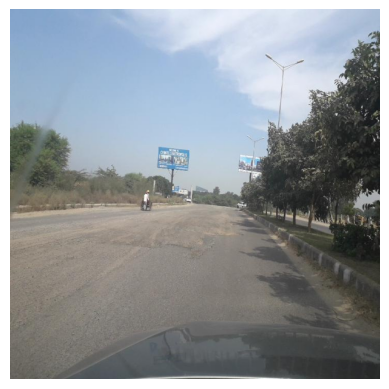

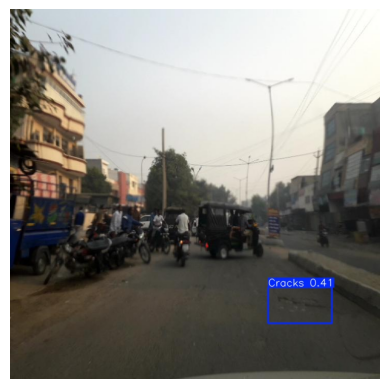

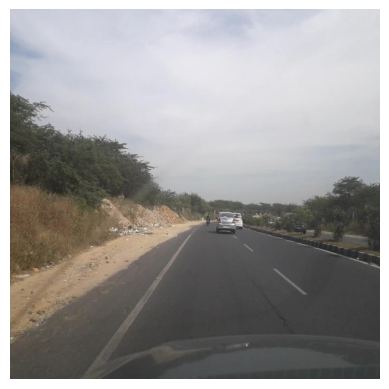

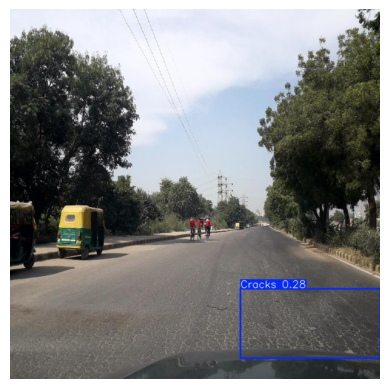

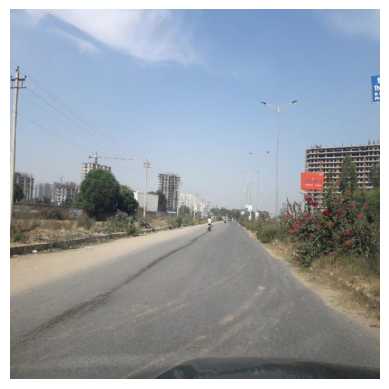

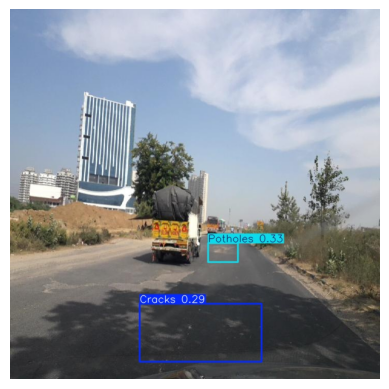

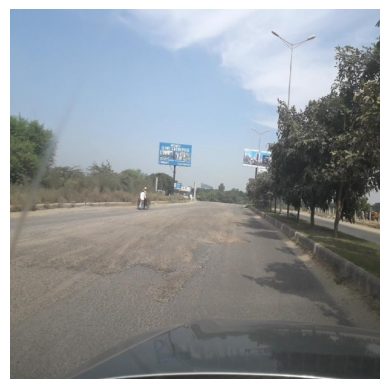

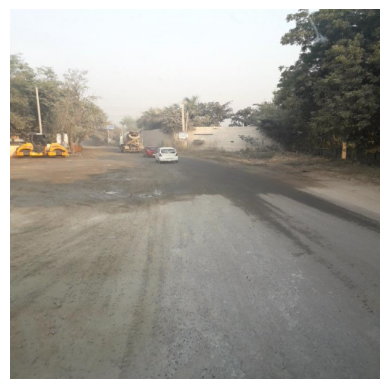

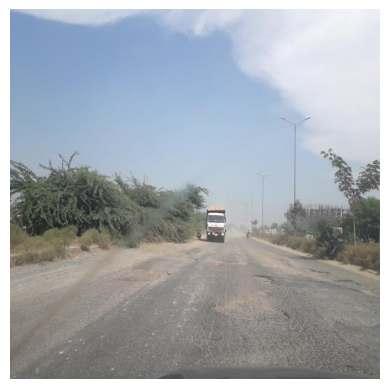

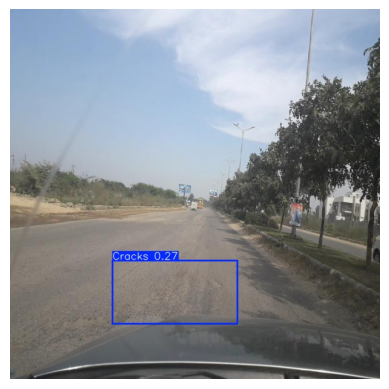

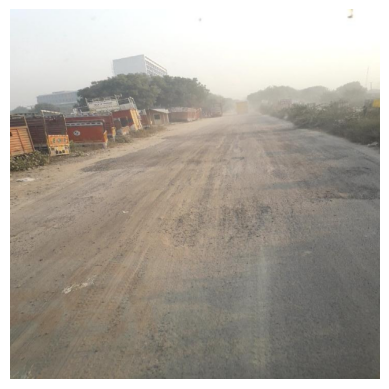

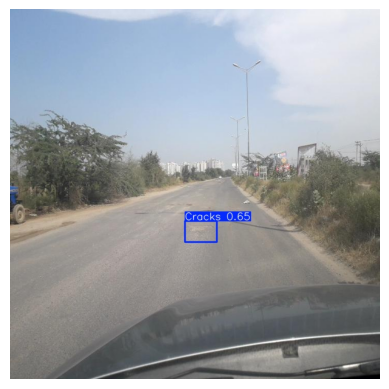

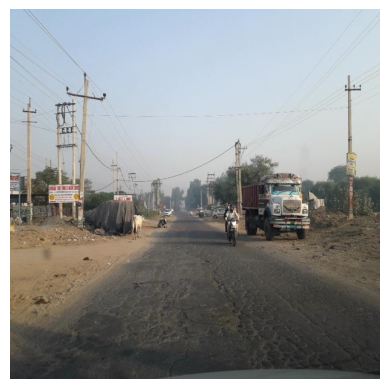

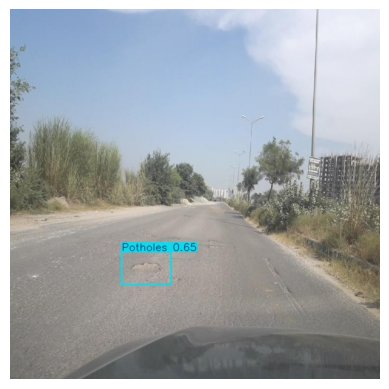

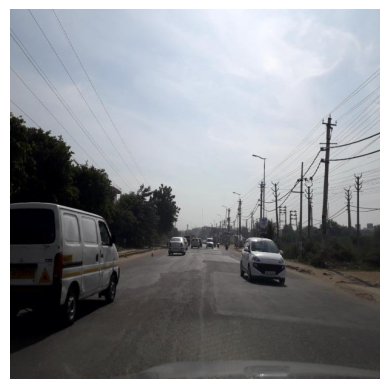

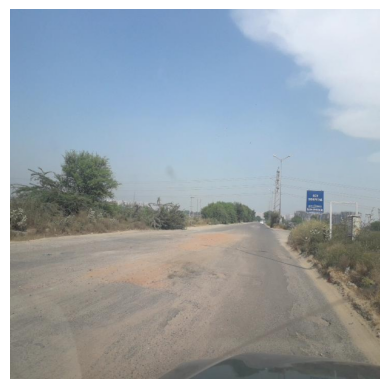

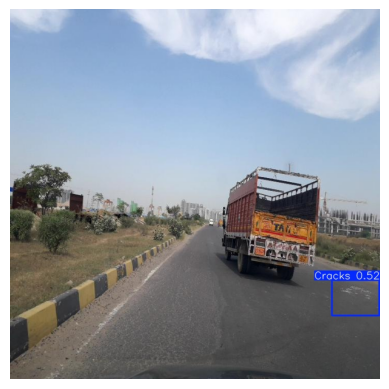

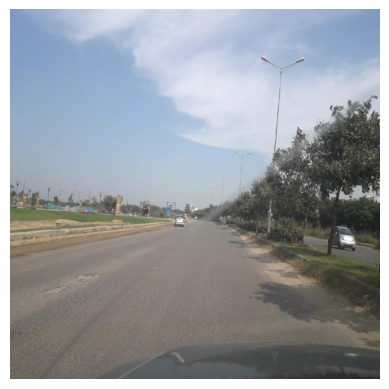

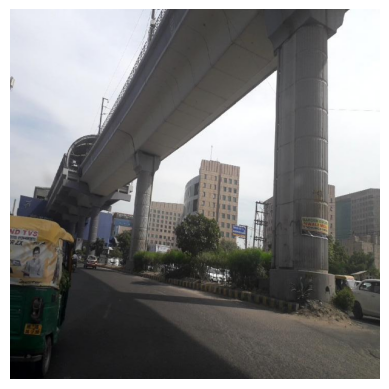

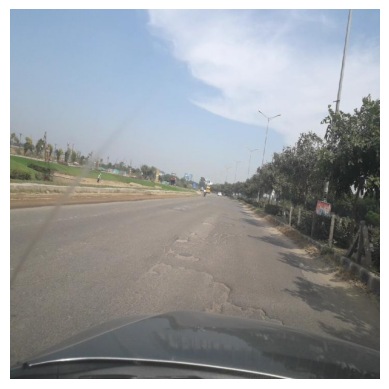

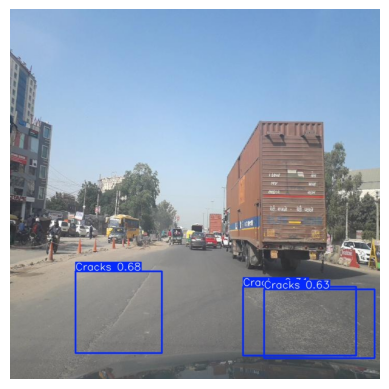

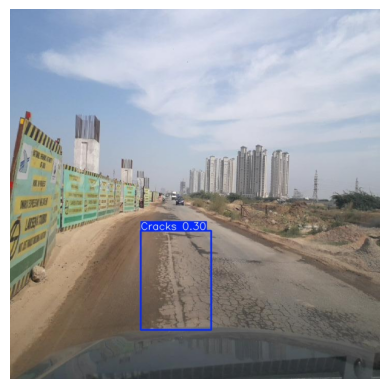

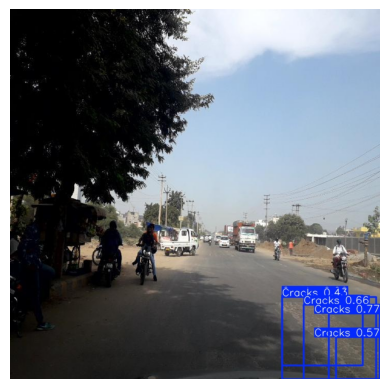

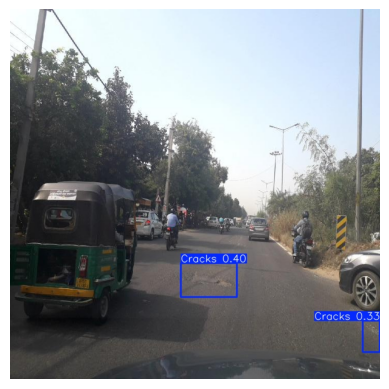

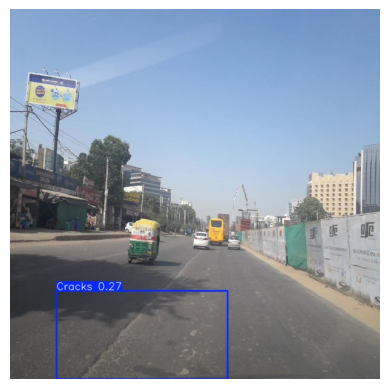

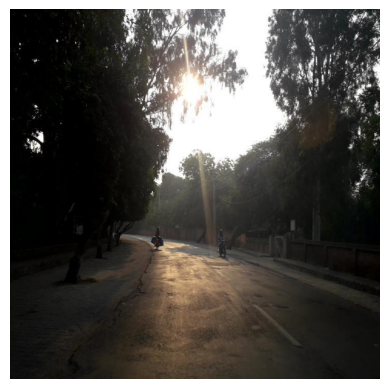

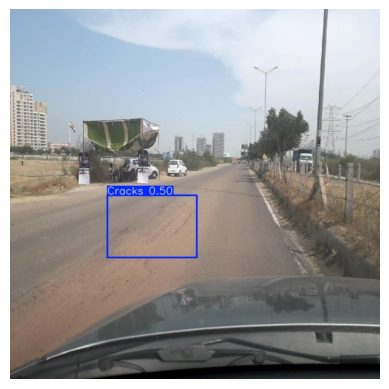

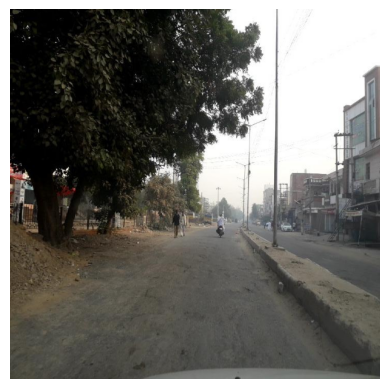

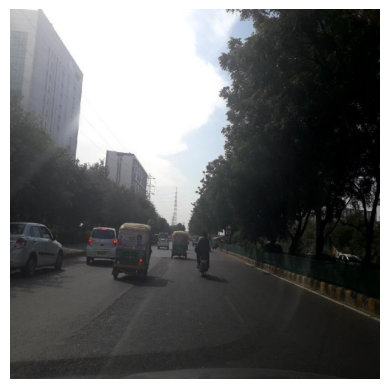

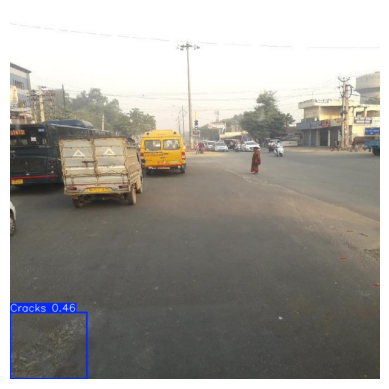

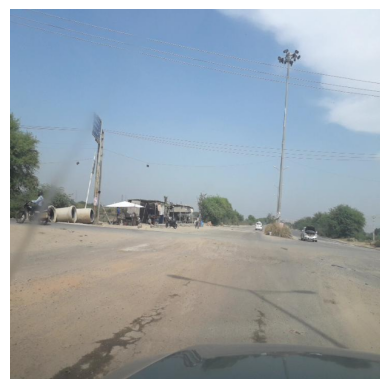

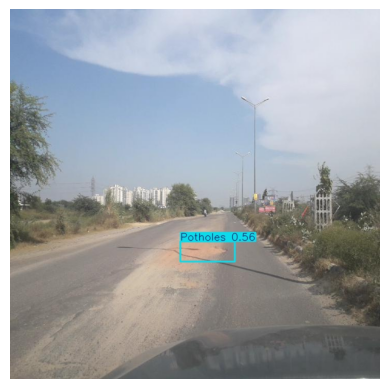

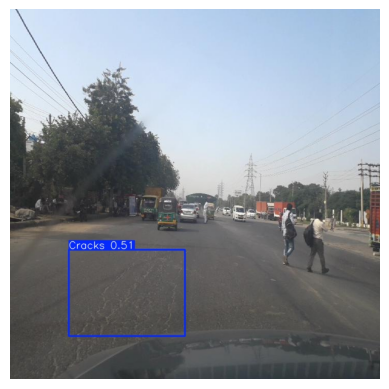

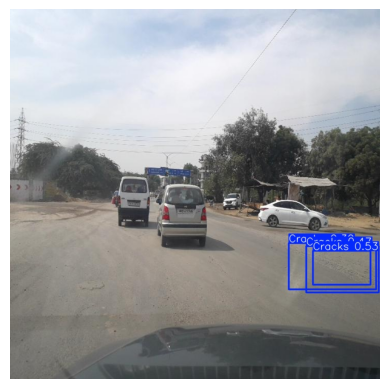

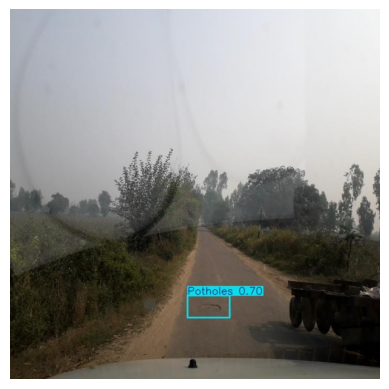

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Display a few predictions
pred_images_dir = 'runs/detect/test_predictions'  # Path to prediction images
for img_file in os.listdir(pred_images_dir):
    if img_file.endswith('.jpg') or img_file.endswith('.png'):
        img_path = os.path.join(pred_images_dir, img_file)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.show()


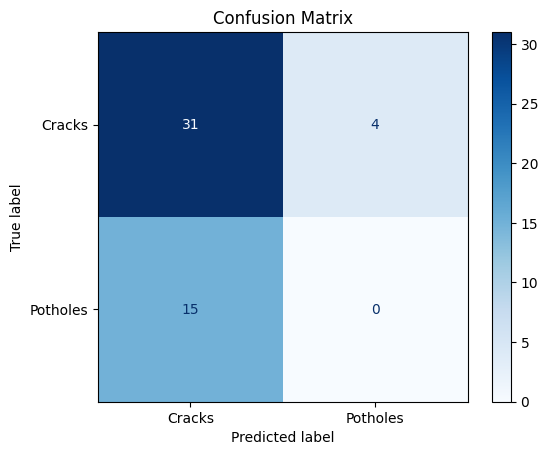

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def read_labels(label_dir):
    """Reads labels from a directory."""
    labels = {}
    for file_name in os.listdir(label_dir):
        if file_name.endswith('.txt'):
            with open(os.path.join(label_dir, file_name), 'r') as file:
                data = [line.strip().split()[0] for line in file.readlines()]  # Get class IDs
                labels[file_name] = list(map(int, data))  # Convert to int
    return labels

# Define paths
ground_truth_dir = '/content/Road-defect-detection-16/test/labels'
pred_label_dir = 'runs/detect/test_predictions/labels'

# Read labels
ground_truth = read_labels(ground_truth_dir)
predictions = read_labels(pred_label_dir)

# Combine predictions and ground truth by matching filenames
y_true, y_pred = [], []
for file_name in ground_truth:
    gt_labels = ground_truth[file_name]
    pred_labels = predictions.get(file_name, [])  # Get predictions or default to empty
    y_true.extend(gt_labels)
    y_pred.extend(pred_labels)

# Handle cases with no predictions
y_pred.extend([0] * (len(y_true) - len(y_pred)))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # Adjust labels as per classes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cracks', 'Potholes'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import roboflow
import os

# Initialize Roboflow with the API key
rf = roboflow.Roboflow(api_key="bbZsMtcHlx6j0OaJ6lJb")
project = rf.workspace("stuti").project("road-defect-detection-2zice")

# Specify version and deploy settings
version = project.version(16)

# Correct paths for images and weights
image_dir = "/content/Road-defect-detection-16/test/images/"  # Ensure this directory exists
weights_path = '/content/yolo_cv_results/fold_4/weights/best.pt'  # Correct path to weights file

# Check if image directory exists
if not os.path.exists(image_dir):
    print(f"Error: The directory {image_dir} does not exist.")
else:
    # Ensure the weights file exists
    if not os.path.exists(weights_path):
        print(f"Error: The weights file {weights_path} does not exist.")
    else:
        print(f"Deploying model with weights from: {weights_path}")
        # Deploy model with the correct paths
        version.deploy("yolov8", image_dir, weights_path)


loading Roboflow workspace...
loading Roboflow project...
Deploying model with weights from: /content/yolo_cv_results/fold_4/weights/best.pt
Dependency ultralytics==8.0.196 is required but found version=8.3.77, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
View the status of your deployment at: https://app.roboflow.com/stuti/road-defect-detection-2zice/16
Share your model with the world at: https://universe.roboflow.com/stuti/road-defect-detection-2zice/model/16
